In [54]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [55]:
og_gemeente_dir = "input/gemeentes/original/Gemeentes2013TrMr.shp"

In [56]:
def find_intersecting_gemeentes_shp(
    og_gemeente_shp     
):
    unique_id_column = "OBJECTID"
    intersecting_gemeentes_found = False
    # Iterating over each geometry and checking for intersections with all other geometries
    for index, row in og_gemeente_shp.iterrows():
        intersecting_gemeentes = og_gemeente_shp[
            (og_gemeente_shp.geometry.intersects(row.geometry)) &
            (~og_gemeente_shp.geometry.touches(row.geometry)) &
            (og_gemeente_shp.index != index)
        ][unique_id_column].tolist()

        # Printing the gemeente OBJECTID and its intersecting gemeente OBJECTID
        if intersecting_gemeentes:
            intersecting_gemeentes_found = True  # Mark that at least one intersection was found

            # Printing the gemeente OBJECTID and its intersecting gemeente OBJECTID
            for other_id in intersecting_gemeentes:
                print(f"Gemeente {row[unique_id_column]} intersects with gemeente {other_id}")

    if intersecting_gemeentes_found == False:
        print("No intersecting gemeentes found")

In [57]:
def plot_intersecting_gemeentes(
  og_gemeente_shp
):
  # Plotting gemeentes 392 and 30
  fig_1, ax_1 = plt.subplots(1, 2, figsize=(10, 5))
  fig_1.suptitle("Intersecting gemeentes", fontsize = 20)

  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==392].plot(ax=ax_1[0], color="red", alpha=0.3, edgecolor="green", linewidth=3)
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==30].plot(ax=ax_1[0], color="blue", alpha=0.3, edgecolor="black", linewidth=3)
  ax_1[0].set_title("Gemeentes 392 and 30")

  # Plotting gemeentes 153 and 43
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==143].plot(ax=ax_1[1], color="red", alpha=0.3, edgecolor="green", linewidth=3)
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==153].plot(ax=ax_1[1], color="blue", alpha=0.3, edgecolor="black", linewidth=3)
  ax_1[1].set_title("Gemeentes 143 and 153")

In [58]:
# The correct gemeente borders were cross checked with CBS data from 2013

def correct_intersecting_gemeentes_30_392(
    og_gemeente_shp
):
  fig_1, ax_1 = plt.subplots(1, 2, figsize=(10, 5))
  fig_1.suptitle("Gemeentes 392 and 30 before and after correction")

  # Subplot for before correction
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==392].plot(ax=ax_1[0], color="red", alpha=0.3, linewidth=3)
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==30].plot(ax=ax_1[0], color="blue", alpha=0.3, linewidth=3)

  # Loading the gemeente polygons
  left_gemeente_392 = og_gemeente_shp[og_gemeente_shp["OBJECTID"]==392].geometry.values[0]
  right_gemeente_30 = og_gemeente_shp[og_gemeente_shp["OBJECTID"]==30].geometry.values[0]

  # The correct polygon 392 would be the union of it with the intersecting polygon of the gemeentes
  # The correct polygon 30 would be the difference of it with the intersecting polygon of the gemeentes
  intersecting_polygon = left_gemeente_392.intersection(right_gemeente_30)

  corrected_gemeente_392 = left_gemeente_392.union(intersecting_polygon)
  corrected_gemeente_30 = right_gemeente_30.difference(intersecting_polygon)

  # Replacing the polygons
  og_gemeente_shp.loc[og_gemeente_shp["OBJECTID"]==392, "geometry"] = corrected_gemeente_392
  og_gemeente_shp.loc[og_gemeente_shp["OBJECTID"]==30, "geometry"] = corrected_gemeente_30

  # Subplot for after correction
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==392].plot(ax=ax_1[1], color="red", alpha=0.3, linewidth=3)
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==30].plot(ax=ax_1[1], color="blue", alpha=0.3, linewidth=3)

  return(og_gemeente_shp)

def correct_intersecting_gemeentes_143_153(
  og_gemeente_shp
):

  fig_1, ax_1 = plt.subplots(1, 2, figsize=(10, 5))
  fig_1.suptitle("Gemeentes 143 and 153 before and after correction")

  # Subplot for before correction
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==143].plot(ax=ax_1[0], color="red", alpha=0.3)
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==153].plot(ax=ax_1[0], color="blue", alpha=0.3)
  ax_1[0].set_title("Before correction")

  # Correcting geometries 143 and 153
  outer_polygon_143 = og_gemeente_shp[og_gemeente_shp["OBJECTID"]==143].geometry.values[0]
  inner_polygon_153 = og_gemeente_shp[og_gemeente_shp["OBJECTID"]==153].geometry.values[0]

  corrected_polygon_143 = outer_polygon_143.difference(inner_polygon_153)

  # Replacing the 143 polygon with the corrected polygon
  og_gemeente_shp.loc[og_gemeente_shp["OBJECTID"]==143, "geometry"] = corrected_polygon_143

  # Subplot for after correction
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==143].plot(ax=ax_1[1], color="red", alpha=0.3, linewidth=3)
  og_gemeente_shp[og_gemeente_shp["OBJECTID"]==153].plot(ax=ax_1[1], color="blue", alpha=0.3, linewidth=3)

  return og_gemeente_shp

Gemeente 30 intersects with gemeente 392
Gemeente 143 intersects with gemeente 153
Gemeente 153 intersects with gemeente 143
Gemeente 392 intersects with gemeente 30
No intersecting gemeentes found


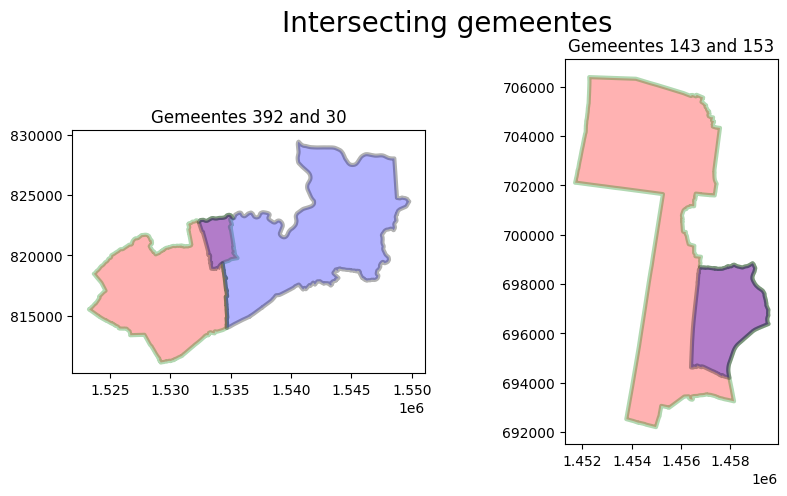

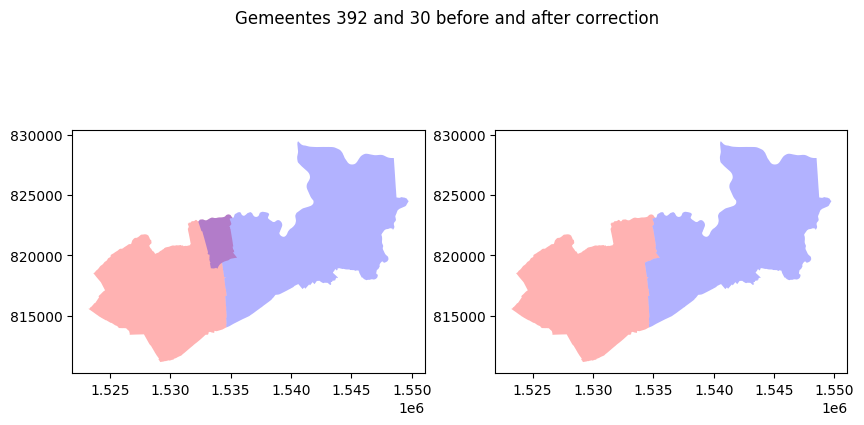

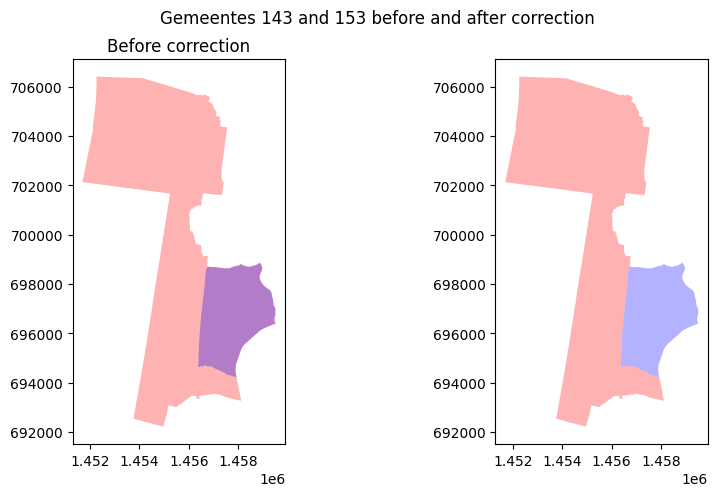

In [59]:
og_gemeente_shp = gpd.read_file(og_gemeente_dir)
find_intersecting_gemeentes_shp(og_gemeente_shp)
plot_intersecting_gemeentes(og_gemeente_shp)
corrected_shp = correct_intersecting_gemeentes_30_392(og_gemeente_shp)
corrected_shp = correct_intersecting_gemeentes_143_153(og_gemeente_shp)

find_intersecting_gemeentes_shp(corrected_shp)
corrected_shp.to_file("input/gemeentes/corrected/Gemeentes2013TrMr.shp")

In [8]:
import geopandas as gpd
import re

imm_start_pop_dir = "input/gemeentes/points/test.shp"
gdf_imm = gpd.read_file(imm_start_pop_dir)

In [9]:
gdf_imm[["S19111"]]

,S19111
0,429.86
1,214.99
2,515.30
3,455.79
4,473.09
...,...
391,357.49
392,795.05
393,372.60
394,750.79


In [7]:
s_cols = [col for col in gdf_imm.columns if re.match("^[Ss]\d{5}$", col)]  
for col in s_cols:
    gdf_imm[col] = (
        gdf_imm[col]
        .astype(str)
        .str.replace(".", "", regex=False)   # remove thousand separators
        .str.replace(",", ".", regex=False)  # convert commas to dots
        .astype(float)
    )

gdf_imm[["S19111"]]

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/62/l81_5d_d7zs42vvzm3fgcr9m0000gn/T/ipykernel_37359/1921494874.py:1: SyntaxWarning: invalid escape sequence '\d'
  s_cols = [col for col in gdf_imm.columns if re.match("^[Ss]\d{5}$", col)]


,S19111
0,429860.0
1,214990.0
2,51530.0
3,455790.0
4,473090.0
...,...
391,357490.0
392,795050.0
393,37260.0
394,750790.0


In [10]:
import rioxarray

# Input NetCDF file and variable name
nc_path = "input/foi.nc"
tif_path = "input/foi.tif"

# Open NetCDF
ds = rioxarray.open_rasterio(nc_path)

# If your file has multiple variables, inspect first
print(ds)

# Select a variable (if needed)
# ds = ds.sel(variable="infection_rate")

# Export to GeoTIFF
ds.rio.to_raster(tif_path)

print(f"✅ Saved GeoTIFF: {tif_path}")


<xarray.DataArray 'foi' (band: 1, y: 68, x: 48)> Size: 13kB
[3264 values with dtype=float32]
Coordinates:
  * band     (band) int64 8B 1
  * x        (x) float64 384B 1.349e+05 1.351e+05 ... 1.441e+05 1.443e+05
  * y        (y) float64 544B 4.684e+05 4.682e+05 ... 4.552e+05 4.55e+05
    crs      int64 8B 0
Attributes:
    easting#long_name:   easting
    easting#units:       meter
    Conventions:         CF-1.4
    created_by:          R packages ncdf4 and terra (version 1.8-29)
    created_date:        2025-05-05 10:17:08
    northing#long_name:  northing
    northing#units:      meter
    _FillValue:          -1.175494e+38
    scale_factor:        1.0
    add_offset:          0.0
✅ Saved GeoTIFF: input/foi.tif


In [2]:
import rasterio
from rasterio import shutil as rio_shutil
import geopandas as gpd

# Input and output file paths
input_tif = "../imbit_model/data/input/pop_raster/pop_total_percell.tif"
output_asc = "../imbit_model/data/input/pop_raster/pop_total_percell.asc"

shp_dir = "input/gemeentes/points/StartPopulationHighR70TrMr.shp" 
shapefile = gpd.read_file(shp_dir)
target_crs = shapefile.crs

# Open the input TIFF
with rasterio.open(input_tif) as src:
    # Copy to ASCII format using rasterio's driver
    rio_shutil.copy(src, output_asc, driver='AAIGrid')

print(f"Saved ASCII raster to: {output_asc}")


Saved ASCII raster to: ../imbit_model/data/input/pop_raster/pop_total_percell.asc


In [4]:
import rasterio
from rasterio import shutil as rio_shutil
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gpd

# === Input and output file paths ===
input_tif = "../imbit_model/data/input/pop_raster/pop_total_percell.tif"
output_asc = "../imbit_model/data/input/pop_raster/pop_total_percell_2.asc"

input_tif = "../imbit_model/data/input/foi/foi.tif"
output_asc = "../imbit_model/data/input/foi/foi.asc"
shp_dir = "input/gemeentes/points/StartPopulationHighR70TrMr.shp"

# === Read shapefile CRS ===
shapefile = gpd.read_file(shp_dir)
target_crs = shapefile.crs

# === Open the input TIFF ===
with rasterio.open(input_tif) as src:
    if src.crs != target_crs:
        print(f"Reprojecting raster from {src.crs} → {target_crs}")

        # Calculate new transform and dimensions
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )

        # Update metadata
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': target_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Temporary reprojected file
        temp_tif = "../imbit_model/data/input/pop_raster/temp_reprojected.tif"

        # Reproject and write to temporary GeoTIFF
        with rasterio.open(temp_tif, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=Resampling.nearest  # use bilinear/cubic if continuous
                )

        # Convert reprojected GeoTIFF to ASCII
        with rasterio.open(temp_tif) as reproj_src:
            rio_shutil.copy(reproj_src, output_asc, driver='AAIGrid')

    else:
        print("CRS already matches shapefile. Converting directly to ASCII...")
        rio_shutil.copy(src, output_asc, driver='AAIGrid')

print(f"✅ Saved ASCII raster to: {output_asc}")


Reprojecting raster from EPSG:28992 → EPSG:2157
✅ Saved ASCII raster to: ../imbit_model/data/input/foi/foi.asc
